# 01 · Análise exploratória

**Tech Challenge Fase 3: Indicador Criança Alfabetizada**

O enunciado pede que o projeto **comece** pela análise exploratória e que ela *"apoie diretamente as decisões de modelagem"*. Este notebook segue os seis itens da página 4 do PDF, e cada seção termina em uma **decisão** ou em uma **hipótese**.

| Seção | Item do enunciado |
|---|---|
| 1 | Compreender o comportamento dos dados |
| 2 | Avaliar distribuições |
| 3 | Detectar correlações |
| 4 | Identificar padrões |
| 5 | Analisar variáveis relevantes |
| 6 | Formular hipóteses analíticas |

O código fica em `src/visualization/analise_exploratoria.py`, e o notebook chama as funções de lá. Assim existe **uma única versão** de cada cálculo: o script roda no pipeline, e o notebook conta a história.

**Pré-requisito:** rodar antes `construir_base_analitica.py` e `enriquecer_base.py` (ver README principal).

In [1]:
import sys
from pathlib import Path
from IPython.display import Image, display

# O notebook roda a partir de notebooks/. Subimos um nível para chegar
# à raiz do projeto e tornamos o script de EDA importável.
RAIZ = Path.cwd().parent
sys.path.insert(0, str(RAIZ / "src" / "visualization"))

import analise_exploratoria as eda

base = eda.ler_base()
base.head()

,sigla_uf,regiao,taxa_2023,media_portugues_2023,participacao_2023,meta_2024,meta_2030,_auditoria_taxa_2024,nivel_oficial_2023,esforco_exigido,distancia_2030,atingiu_meta,nome_municipio,microrregiao,mesorregiao,regiao_imediata,regiao_intermediaria,populacao,log_populacao,porte_municipio
id_municipio,,,,,,,,,,,,,,,,,,,,
1100015,RO,Norte,64.55,758.3304,89.37,67.08,80.0,67.79,3.0,2.53,15.45,1,Alta Floresta D'Oeste,Cacoal,Leste Rondoniense,Cacoal,Ji-Paraná,22516.0,10.022026,pequeno_II
1100023,RO,Norte,62.30,757.0999,89.79,65.22,80.0,65.62,3.0,2.92,17.70,1,Ariquemes,Ariquemes,Leste Rondoniense,Ariquemes,Porto Velho,111148.0,11.618627,grande
1100031,RO,Norte,69.10,767.8763,90.48,70.85,80.0,75.88,3.0,1.75,10.90,1,Cabixi,Colorado do Oeste,Leste Rondoniense,Vilhena,Ji-Paraná,5067.0,8.530702,pequeno_I
1100049,RO,Norte,62.51,755.5645,84.44,65.39,80.0,65.81,3.0,2.88,17.49,1,Cacoal,Cacoal,Leste Rondoniense,Cacoal,Ji-Paraná,86416.0,11.366940,medio
1100056,RO,Norte,58.53,746.4629,92.12,62.09,80.0,66.81,2.0,3.56,21.47,1,Cerejeiras,Colorado do Oeste,Leste Rondoniense,Vilhena,Ji-Paraná,16088.0,9.685891,pequeno_I


## 1. Comportamento geral dos dados

**Perguntas:** quantos municípios temos? O alvo está equilibrado? Há dados faltando? Algum estado ficou de fora?

In [2]:
geral = eda.visao_geral(base)


  1. Comportamento geral dos dados
  ------------------------------------------------------------------------
    municipios              : 5232
    colunas                 : 20
    UFs representadas       : 24
    atingiram a meta        : 2788 (53.3%)
    nao atingiram           : 2444 (46.7%)
    -> classes equilibradas: acuracia e AUC sao interpretaveis
       sem rebalanceamento
    nulos                   : nenhum
    -> a imputacao na pipeline existe como protecao para dados
       novos, que podem chegar incompletos
    UFs ausentes            : AC, DF, RR
      DF: nao possui municipios nem rede municipal (estrutural)
      AC, RR: sem municipios com rede municipal na base


**O que encontramos**

- **5.232 municípios**, com **53,3%** tendo atingido a meta. Esse equilíbrio perto de 50/50 permite ler acurácia e AUC sem técnicas de rebalanceamento (SMOTE, pesos de classe).
- **Nenhum nulo** na base atual. A imputação continua na pipeline como proteção, porque dados novos podem chegar incompletos.
- **Três UFs ausentes**, por razões diferentes:
  - **DF**: Brasília não é município. O Distrito Federal acumula funções de estado e município e não tem rede municipal. A ausência é **estrutural**.
  - **AC e RR**: nenhum município com rede municipal nesta avaliação. Toda conclusão do projeto é silenciosa sobre esses dois estados.

➡️ **Decisão:** classificação binária sem rebalanceamento; imputação mantida na pipeline.

## 2. Distribuições por classe

**Pergunta:** as variáveis se comportam de forma diferente entre quem atingiu e quem não atingiu a meta?

Se as curvas azul e terracota se sobrepõem, a variável sozinha não separa as classes. Se uma está deslocada em relação à outra, há sinal.


  2. Distribuicoes por classe
  ------------------------------------------------------------------------
    taxa_2023              media atingiu    60.05 | nao atingiu    60.98 | assimetria -0.13
    esforco_exigido        media atingiu     1.41 | nao atingiu     1.96 | assimetria -2.01
    participacao_2023      media atingiu    90.90 | nao atingiu    88.58 | assimetria -0.63
    log_populacao          media atingiu     9.42 | nao atingiu     9.60 | assimetria +0.80


    -> images/eda_distribuicoes.png
    populacao sem log: assimetria +38.1 -> justifica usar log_populacao


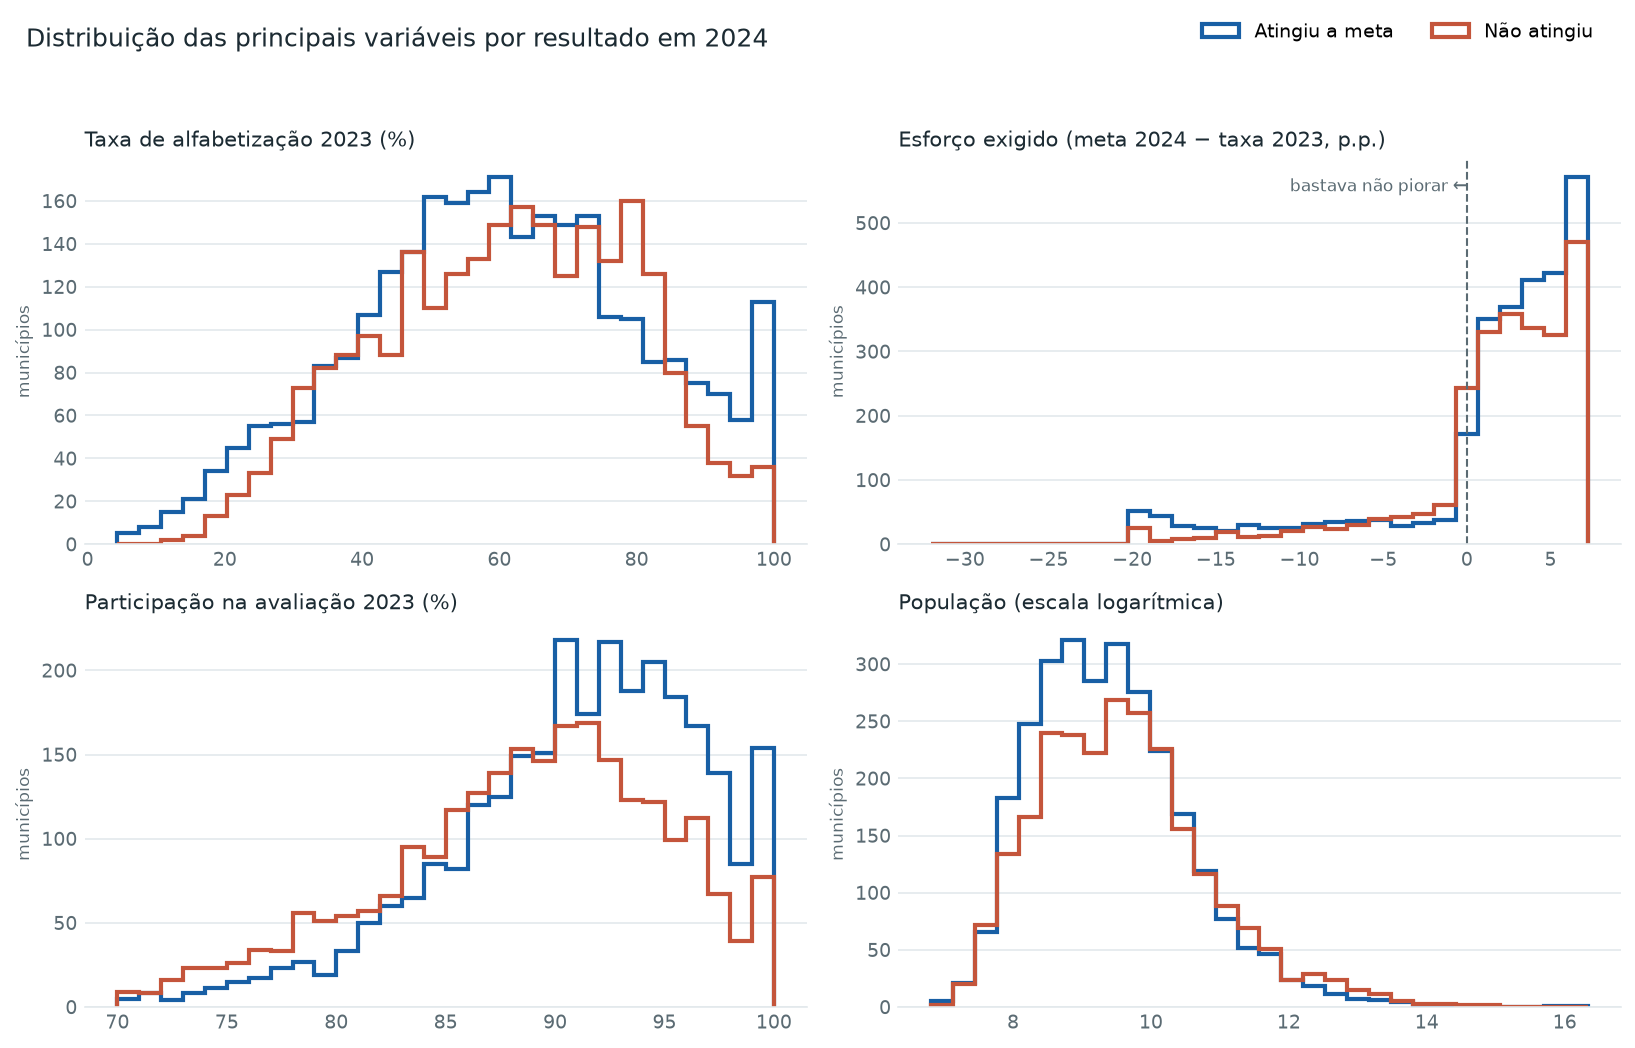

In [3]:
dist = eda.distribuicoes(base)
display(Image(RAIZ / "images" / "eda_distribuicoes.png"))

**O que encontramos**

- **Taxa de 2023:** as duas curvas quase se sobrepõem. **Ir bem em 2023 não garante atingir a meta de 2024**, porque a meta de cada município é calculada a partir do seu próprio ponto de partida. Quem parte alto recebe meta alta.
- **Esforço exigido:** existe uma massa de municípios à esquerda do zero, que **só precisavam não piorar**. Mesmo ali há muitas linhas terracota (seção 6.1).
- **Participação:** a curva azul está **deslocada para a direita**. É o sinal mais visível entre as numéricas.
- **População:** as curvas quase coincidem, com uma leve vantagem dos municípios **menores**. Sem logaritmo, a assimetria da população passa de **+38** (poucas metrópoles puxando a cauda); no log ela cai para perto de zero.

➡️ **Decisões:** usar `log_populacao` em vez de `populacao`; investigar a participação (hipótese da seção 6.2).

## 3. Correlações e redundâncias

**Pergunta:** existem variáveis que carregam a mesma informação?

Duas variáveis muito correlacionadas não atrapalham a **previsão**, mas atrapalham a **interpretação**: o modelo divide a importância entre elas de forma instável.


  3. Correlacoes e redundancias
  ------------------------------------------------------------------------
    [CONSTANTE] meta_2030 = 80.0 em todos os municipios
    pares com |r| > 0.8: 13
      taxa_2023              x distancia_2030         -1.000  <- mesma informacao
      taxa_2023              x meta_2024              +0.979
      meta_2024              x distancia_2030         -0.979
      taxa_2023              x nivel_oficial_2023     +0.969
      nivel_oficial_2023     x distancia_2030         -0.969
      meta_2024              x nivel_oficial_2023     +0.959
      taxa_2023              x media_portugues_2023   +0.931
      media_portugues_2023   x distancia_2030         -0.931
      media_portugues_2023   x nivel_oficial_2023     +0.884
      media_portugues_2023   x meta_2024              +0.881
      media_portugues_2023   x esforco_exigido        -0.866
      taxa_2023              x esforco_exigido        -0.848
      esforco_exigido        x distancia_2030         +

    -> images/eda_correlacoes.png
    -> decisoes:
       remover meta_2030 (constante)
       remover distancia_2030 (duplica taxa_2023)
       os demais pares ficam, mas a importancia das variaveis
       precisa de teste de estabilidade (multicolinearidade)


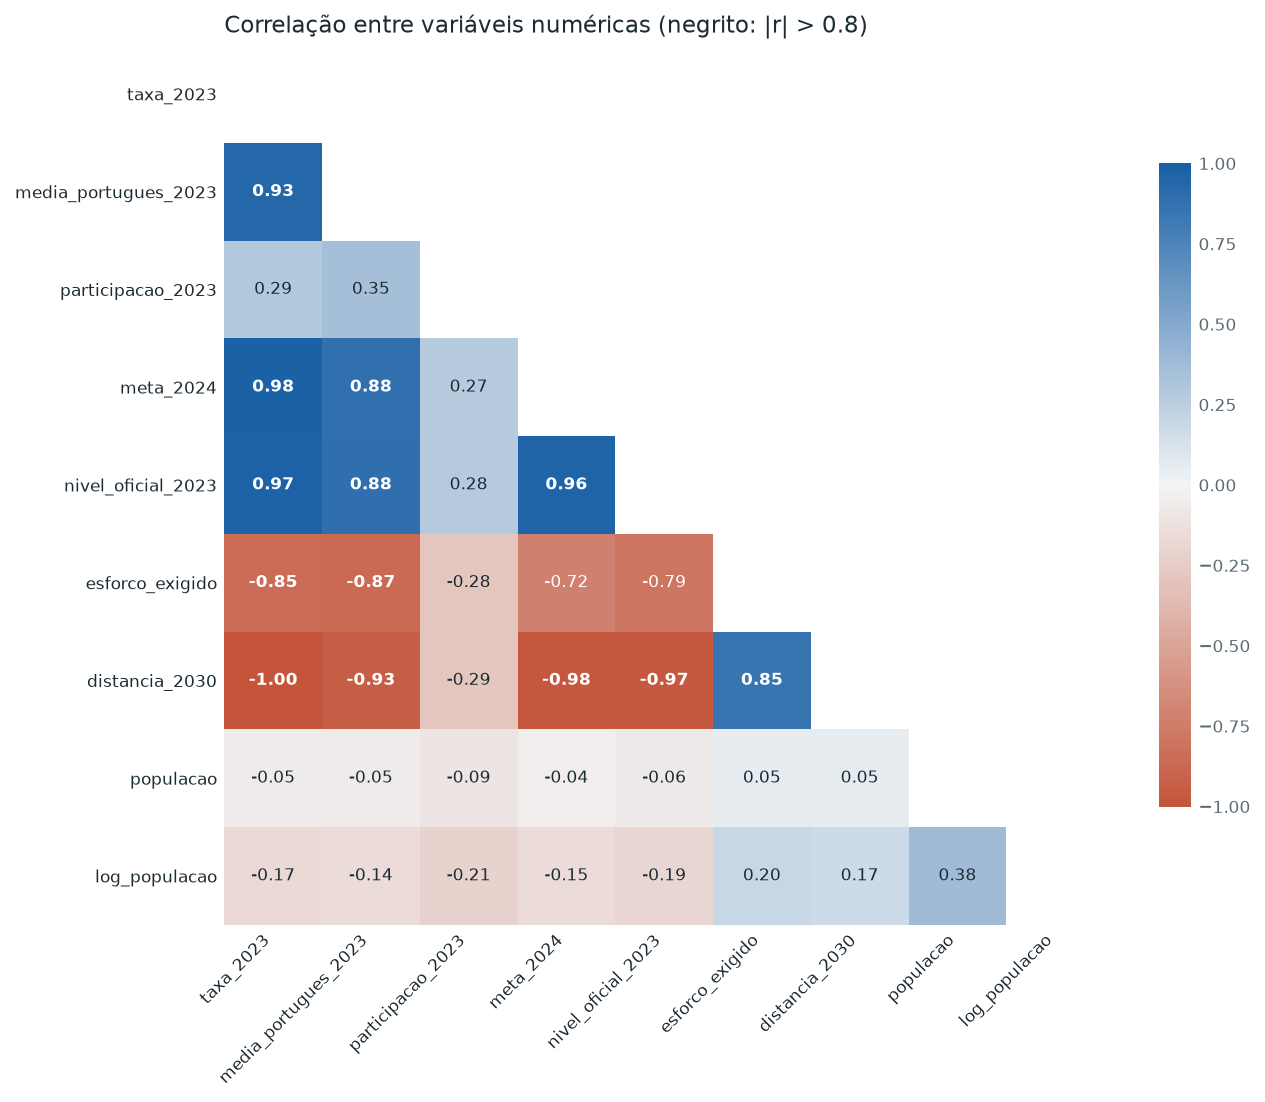

In [4]:
corr = eda.correlacoes(base)
display(Image(RAIZ / "images" / "eda_correlacoes.png"))

**O que encontramos**

- **`meta_2030` é constante:** vale 80 em todos os municípios. Variância zero não carrega informação.
- **`distancia_2030` tem correlação −1,000 com `taxa_2023`.** Ela é, literalmente, `80 − taxa_2023`. Nós a criamos achando que capturava "desafio de longo prazo", e a matriz mostrou que era a mesma variável com outro nome. **É para isso que a EDA existe.**
- **13 pares com |r| > 0,80**, quase todos em torno do bloco de desempenho (taxa, média de português, nível oficial, meta).

➡️ **Decisões:**
- remover `meta_2030` e `distancia_2030` (lista `DESCARTADAS` em `treinar_modelo.py`);
- manter os demais pares, mas **testar a estabilidade** do ranking de importância com várias sementes (`interpretar_modelo.py`).

## 4. Padrões territoriais e de porte

**Pergunta:** o atingimento da meta varia por território? E por tamanho do município?


  4. Padroes: atingimento por UF e por porte
  ------------------------------------------------------------------------
    media nacional: 53.3%
    maior: CE 91.3%   menor: RS 9.5%   amplitude 82 p.p.


    -> images/eda_atingimento_por_uf.png
    por porte populacional:
      grande         295 municipios   43.4%
      medio          341 municipios   45.5%
      metropole       17 municipios   35.3%  (amostra pequena)
      pequeno_I     3506 municipios   55.6%
      pequeno_II    1073 municipios   51.1%
    -> variacao entre portes: 12 p.p. contra 82 p.p. entre UFs
       hipotese: territorio pesa mais que tamanho


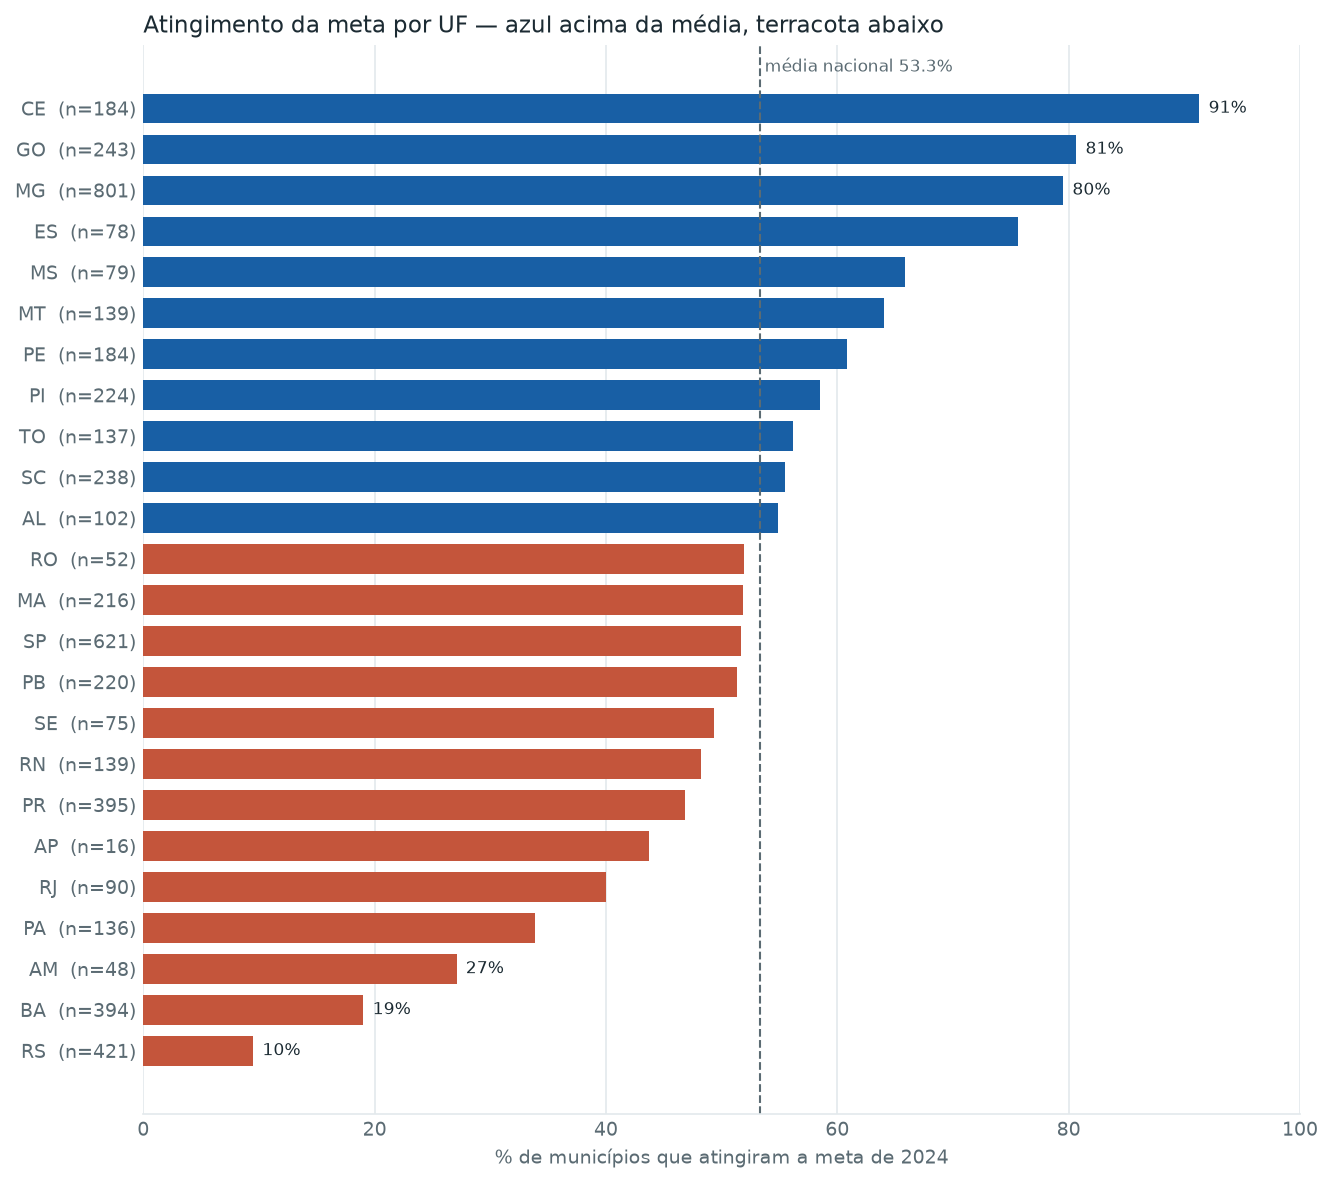

In [5]:
pad = eda.padroes(base)
display(Image(RAIZ / "images" / "eda_atingimento_por_uf.png"))

**O que encontramos**

- A amplitude entre estados é enorme: **Ceará 91%** contra **Rio Grande do Sul 10%**, uma diferença de **82 pontos percentuais**.
- Entre faixas de porte, a variação é de **12 pontos**, e no sentido oposto ao do senso comum: os municípios **pequenos** atingem mais a meta (≈56%) do que os **grandes** (≈43%).
- Algumas UFs têm poucos municípios (o `n` ao lado da sigla). Percentuais de amostras pequenas oscilam mais e merecem cautela.

➡️ **Hipótese:** *o território pesa muito mais que o tamanho* — 82 pontos contra 12. O modelo confirmou: `sigla_uf` ficou em primeiro lugar e a população, com importância quase nula. A vantagem aparente dos municípios pequenos some quando a UF entra no modelo, sinal de que ela vinha, em boa parte, da composição estadual (estados com muitos municípios pequenos são também os de melhor desempenho).

## 5. Poder de separação de cada variável sozinha

**Pergunta:** usando **uma variável de cada vez**, quanto dá para separar quem atinge de quem não atinge?

A medida é a **AUC univariada**: 0,5 significa que a variável não separa nada (equivale a jogar uma moeda); quanto mais perto de 1, mais ela separa.

Para as categóricas (UF, região, porte), cada categoria é trocada pela taxa de atingimento do seu grupo, calculada **por validação cruzada**: a taxa de cada município é calculada sem ele próprio. Calcular com ele dentro vazaria o alvo e inflaria o resultado.

In [6]:
rel = eda.relevancia_individual(base)


  5. Poder de separacao de cada variavel sozinha (AUC univariada)
  ------------------------------------------------------------------------


    sigla_uf (categorica)        0.729  ######################    depende da categoria
    regiao (categorica)          0.640  ##############            depende da categoria
    participacao_2023            0.608  ##########                maior -> mais chance
    populacao                    0.543  ####                      maior -> menos chance
    log_populacao                0.543  ####                      maior -> menos chance
    porte_municipio (categorica) 0.528  ##                        depende da categoria
    meta_2024                    0.520  ##                        maior -> menos chance
    media_portugues_2023         0.516  #                         maior -> mais chance
    taxa_2023                    0.515  #                         maior -> menos chance
    nivel_oficial_2023           0.515  #                         maior -> menos chance
    distancia_2030               0.515  #                         maior -> mais chance
    esforco_exigido              0.511

**O que encontramos**

- **`sigla_uf` sozinha chega a AUC ≈ 0,73.** O modelo completo chega a **0,78**. Ou seja, **a maior parte do poder preditivo vem do estado.**
- **Participação** é a numérica mais forte (≈ 0,61).
- **População** aparece com ≈ 0,54, no sentido "maior → menos chance". É pouco, e o modelo mostra depois que esse pouco desaparece quando a UF está presente.
- As variáveis de desempenho de 2023, **sozinhas, quase não separam** (≈ 0,51–0,52), pelo mesmo motivo da seção 2: a meta acompanha o ponto de partida.

➡️ **Consequência:** esta é a evidência quantitativa por trás da **Limitação 9.1 do README** (ancoragem estadual). Antes mesmo de treinar, a EDA já mostrava que o modelo dependeria muito da UF.

## 6. Hipóteses analíticas

> **Nota sobre o uso da taxa de 2024.** As duas hipóteses abaixo usam `_auditoria_taxa_2024` para **descrever** o fenômeno. Isso é análise descritiva, não modelagem: a coluna continua proibida como variável de entrada, e o script de treino a remove.

### 6.1 Existe um teto de previsibilidade?

Comparamos o **sinal** (quanto o município precisa crescer) com o **ruído** (quanto o indicador oscila naturalmente de um ano para o outro).


  6.1 Hipotese: existe um teto de previsibilidade
  ------------------------------------------------------------------------
    desvio-padrao da variacao 2023 -> 2024 : 16.58 p.p.  (ruido)
    esforco exigido mediano               :  3.15 p.p.  (sinal)
    razao ruido / sinal                   :   5.3x
    municipios com esforco negativo       :  17.6%
      ...e que mesmo assim nao atingiram  :  44.6%
    -> conclusao: AUC muito alta neste problema seria sinal de
       vazamento, nao de um modelo excelente


    -> images/eda_teto_previsibilidade.png


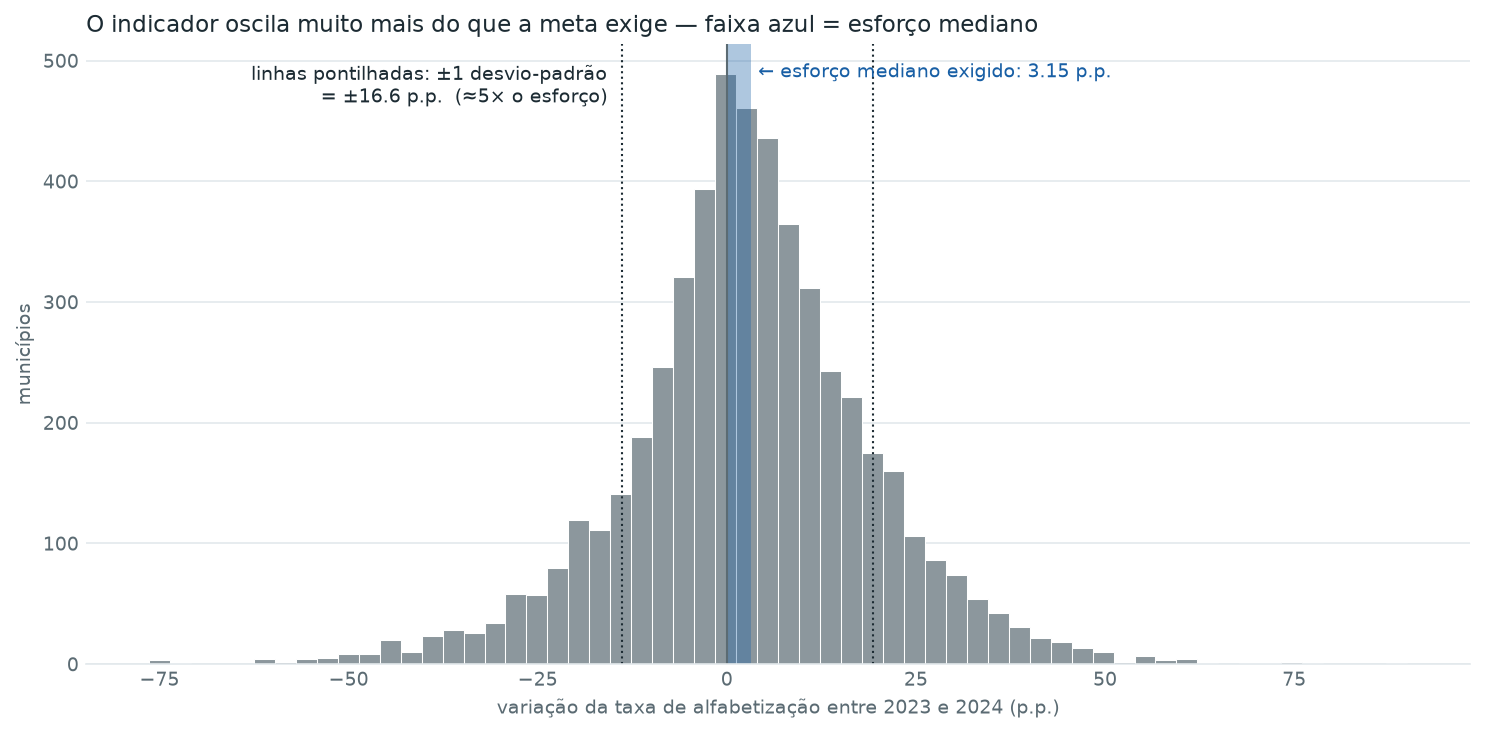

In [7]:
teto = eda.teto_previsibilidade(base)
display(Image(RAIZ / "images" / "eda_teto_previsibilidade.png"))

**O que encontramos**

- O indicador oscila, em desvio-padrão, **16,6 pontos** de um ano para o outro.
- O esforço mediano exigido é de **3,2 pontos**.
- **O ruído é cerca de cinco vezes maior que o sinal.**
- **17,6%** dos municípios só precisavam não piorar, e **44,6%** deles mesmo assim não atingiram a meta.

➡️ **Conclusão:** existe um teto para qualquer modelo com estas variáveis. **Uma AUC muito alta aqui seria sinal de vazamento de dados, não de um modelo excelente.** Isso calibra a leitura do resultado final (AUC 0,78).

### 6.2 A participação importa por ruído ou por gestão?

Duas explicações concorrentes, com previsões **diferentes** (e por isso testáveis):

| | Hipótese A: **ruído** | Hipótese B: **gestão** |
|---|---|---|
| Ideia | Com menos alunos avaliados, o indicador fica mais instável | Redes que levam quase todos à prova são redes mais organizadas |
| Previsão | A **volatilidade** cai quando a participação sobe | A **melhoria média** sobe com a participação |


  6.2 Hipotese: participacao como ruido ou como gestao
  ------------------------------------------------------------------------
    faixa            municipios  volatilidade   melhoria   atingiu
    abaixo de 85%          1070        16.14      +0.28     40.2%
    85% a 95%              3039        16.30      +3.13     53.6%
    95% ou mais            1123        17.46      +4.24     64.9%
    correlacao participacao x |variacao| : +0.045
    -> hipotese A (ruido) REJEITADA: a volatilidade nao cai com a
       participacao
    -> hipotese B (gestao) SUSTENTADA: a melhoria media cresce +4.0 p.p.
       da faixa mais baixa para a mais alta


    -> images/eda_hipotese_participacao.png


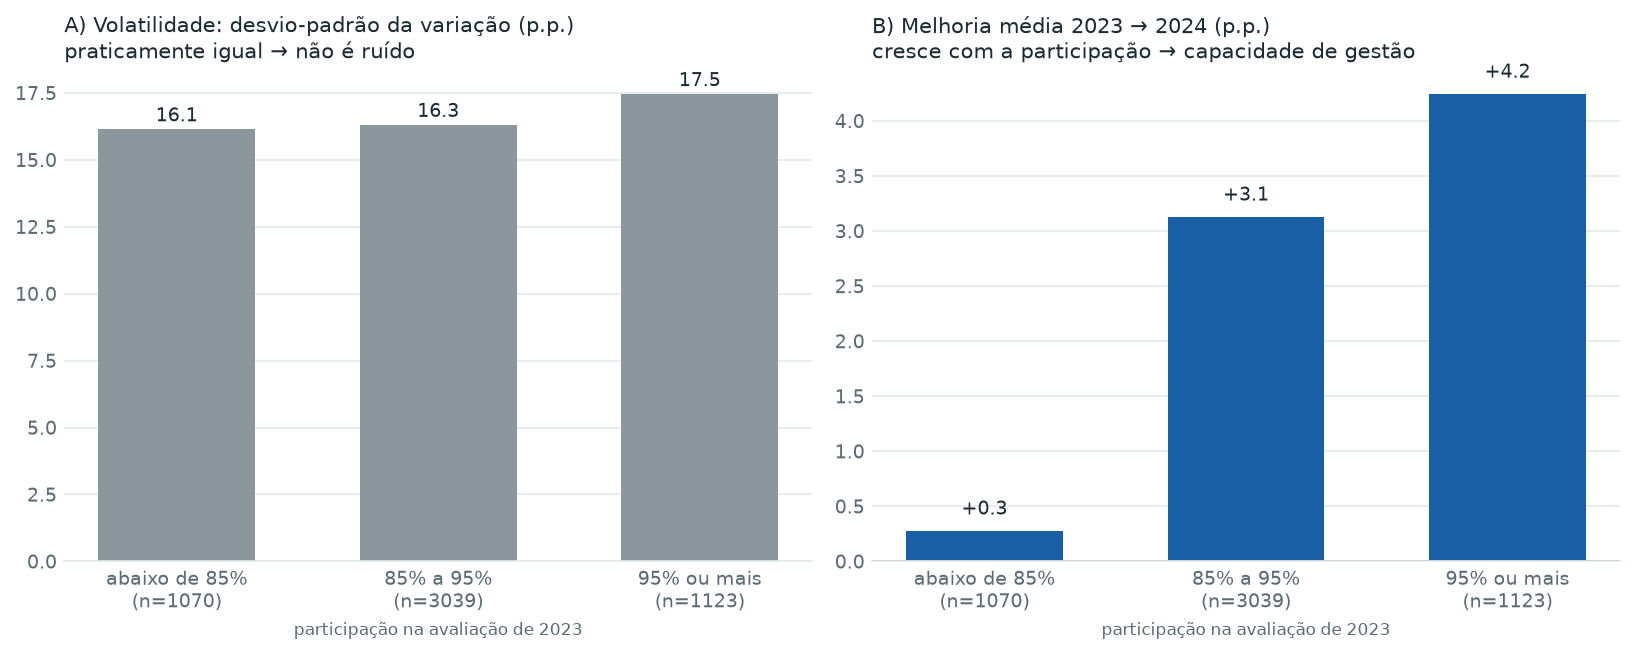

In [8]:
part = eda.hipotese_participacao(base)
display(Image(RAIZ / "images" / "eda_hipotese_participacao.png"))

**O que encontramos**

- **Volatilidade praticamente igual** entre as faixas, e correlação entre participação e tamanho da variação de apenas **+0,045**. → **Hipótese A rejeitada.**
- **Melhoria média cresce de ≈ +0,3 para ≈ +4,2 pontos** da faixa mais baixa para a mais alta, e o atingimento vai de **≈ 40%** para **≈ 65%**. → **Hipótese B sustentada.**

**Registro honesto:** nossa primeira suposição foi a A. O teste mostrou que estava errada. A interpretação correta, **participação como proxy de capacidade de gestão**, só apareceu porque testamos em vez de assumir.

➡️ **Consequência:** participação entra no modelo como variável, e é a base do achado central do projeto (perfil `desafio_com_gestao_ativa`, seção 8.1 do README).

## 7. Síntese: da exploração à modelagem

| Achado da EDA | Decisão de modelagem |
|---|---|
| Classes equilibradas (53,3%) | Sem rebalanceamento; AUC como métrica principal |
| `meta_2030` constante | Removida |
| `distancia_2030` = `80 − taxa_2023` | Removida |
| 13 pares com \|r\| > 0,80 | Teste de estabilidade da importância em 8 sementes |
| População fortemente assimétrica | Transformação logarítmica |
| Amplitude de 82 p.p. entre UFs, contra 12 p.p. entre portes | `sigla_uf` no modelo, com a limitação documentada |
| UF sozinha: AUC ≈ 0,73 | Ancoragem estadual discutida como limitação ética |
| Ruído ≈ 5× o sinal | Expectativa realista de desempenho; alerta contra vazamento |
| Participação = gestão, não ruído | Variável mantida; base dos perfis municipais |

Os números completos ficam em `reports/eda_resumo.json`, gerado pelo script:

```
python src/visualization/analise_exploratoria.py
```